# Import the data annotation json

In [1]:
import json
with open("data/ml/machine-and-movement_complete.json", "r") as f:
    annotation_json = json.load(f)

In [2]:
import pandas as pd

# Convert nested dictionary to DataFrame
rows = []
for instance, events in annotation_json.items():
    for event in events:
        rows.append({
            'Instance': instance,
            'Label': event['label'],
            'Duration': event['duration'],
            'Start': event['start'],
            'End': event['end']
        })

df = pd.DataFrame(rows)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure numeric columns are numeric
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")
df["Start"] = pd.to_numeric(df["Start"], errors="coerce")
df["End"] = pd.to_numeric(df["End"], errors="coerce")

# Clean
df = df.dropna(subset=["Instance", "Label", "Duration", "Start", "End"])

# Optional: fixed order for labels
label_order = ["Clamping", "Bending", "Mandrel Extraction", "De-Clamping"]
df["Label"] = pd.Categorical(df["Label"], categories=label_order, ordered=True)
df = df.sort_values(["Label", "Instance"])

In [4]:
from pathlib import Path
dir = Path("results/activity_recognition/labelStatistic")

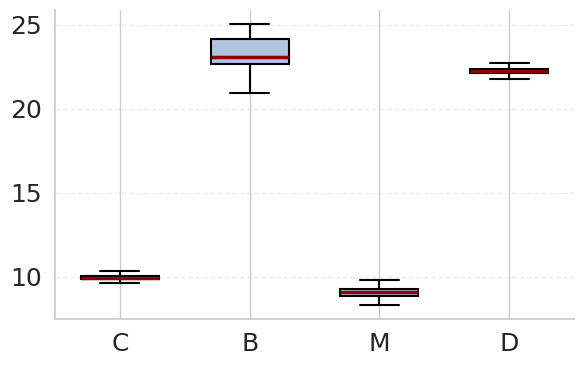

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6,4))

df.boxplot(
    column="Duration",
    by="Label",
    ax=ax,
    vert=True,               # <-- vertical boxplot
    showfliers=False,
    patch_artist=True,
    widths=0.6,
    boxprops=dict(facecolor="lightsteelblue", edgecolor="black", linewidth=1.5),
    medianprops=dict(color="darkred", linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5)
)

# remove automatic titles
ax.set_title("")
fig.suptitle("")

# shorten labels to first character
labels = [tick.get_text()[0] for tick in ax.get_xticklabels()]
ax.set_xticklabels(labels)

# grid styling
ax.grid(axis="y", linestyle="--", alpha=0.35)

# cleaner axes
sns.despine(left=False, bottom=False)

# bigger fonts
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.set_xlabel("")

plt.tight_layout()
plt.savefig(dir / "boxPlot.pdf", dpi=300)
plt.show()

In [10]:
grouped = df.groupby("Label")["Duration"]

stats = grouped.agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

stats["Q1"] = grouped.quantile(0.25)
stats["Q3"] = grouped.quantile(0.75)
stats["IQR"] = stats["Q3"] - stats["Q1"]

# reorder columns
stats = stats[["count", "mean", "median", "Q1", "Q3", "IQR", "min", "max"]]

stats.round(3)

/tmp/ipykernel_11118/563346154.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("Label")["Duration"]


,count,mean,median,Q1,Q3,IQR,min,max
Label,,,,,,,,
Clamping,316,9.920,9.935,9.849,10.045,0.196,0.000,10.551
Bending,315,23.164,23.097,22.673,24.139,1.466,20.939,25.047
Mandrel Extraction,315,9.052,9.074,8.849,9.261,0.412,8.331,9.911
De-Clamping,260,22.282,22.274,22.145,22.389,0.244,21.537,23.199


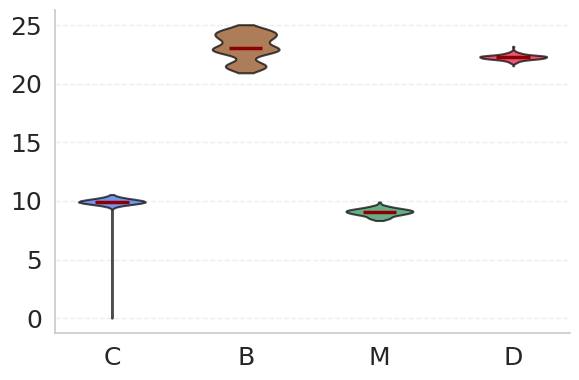

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Clamping", "Bending", "Mandrel Extraction", "De-Clamping"]

# first character only
short_labels = [label[0] for label in labels]

# Prepare grouped data
data = [df[df["Label"] == label]["Duration"] for label in labels]

colors = ["royalblue", "saddlebrown", "seagreen", "crimson"]

# same clean style
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(6,4))

violins = ax.violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Color each violin
for body, color in zip(violins["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_linewidth(1.5)
    body.set_alpha(0.7)

# Median line style
violins["cmedians"].set_color("darkred")
violins["cmedians"].set_linewidth(2.5)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(short_labels)

# clean grid like the boxplot
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

# cleaner axes
sns.despine(left=False, bottom=False)

# font sizes
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.set_xlabel("")

plt.tight_layout(pad=1.2)
plt.savefig(dir / "violon.pdf", dpi=300)
plt.show()

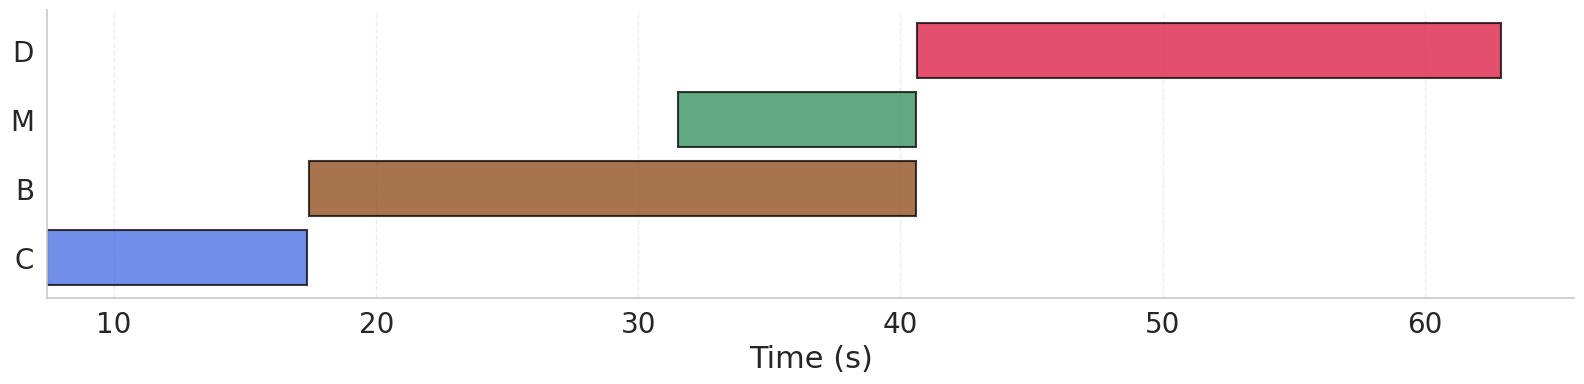

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

range_stats = (
    df.groupby("Label", observed=True)
    .agg(
        mean_start=("Start", "mean"),
        mean_end=("End", "mean"),
        mean_duration=("Duration", "mean"),
    )
    .reindex(label_order)
)

fig, ax = plt.subplots(figsize=(16, 4))

y_positions = range(len(range_stats))

bars = ax.barh(
    y=y_positions,
    width=range_stats["mean_duration"],
    left=range_stats["mean_start"],
    color=["royalblue", "saddlebrown", "seagreen", "crimson"],
    edgecolor="black",
    linewidth=1.5,
    alpha=0.75
)

# first character only
short_labels = [label[0] for label in range_stats.index]

ax.set_yticks(y_positions)
ax.set_yticklabels(short_labels)

# nicer grid
ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

# clean axes
sns.despine(left=False, bottom=False)

# larger fonts
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)

ax.set_xlabel("Time (s)", fontsize=22)
ax.set_ylabel("", fontsize=22)

plt.tight_layout()
plt.savefig(dir / "barchart.pdf", dpi=300)
plt.show()